# Figure Image Classification with ResNet50
Fine-tuned ResNet50 for 7-class figure classification using pre-annotated train/test splits.

## 1. Imports & Configuration

In [1]:
import os
import random
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

# ── Paths ────────────────────────────────────────────────────────────────────
BASE_DIR        = "dataset"
ANNOTATION_DIR  = os.path.join(BASE_DIR, "annotation")
IMAGE_DIR       = os.path.join(BASE_DIR, "images")
TRAIN_TXT       = os.path.join(ANNOTATION_DIR, "train.txt")
TEST_TXT        = os.path.join(ANNOTATION_DIR, "test.txt")
MODEL_SAVE_PATH = "resnet50_figure_classifier.pth"

# ── Hyperparameters ───────────────────────────────────────────────────────────
BATCH_SIZE  = 32
NUM_EPOCHS  = 20
LR          = 1e-4          # learning rate for fine-tuning
LR_HEAD     = 1e-3          # higher LR for the new classifier head
IMG_SIZE    = 224
NUM_WORKERS = 4

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


## 2. Dataset

In [2]:
CLASSES = [
    "graph",
    "table",
    "diagram",
    "meta figure",
    "photograph",
    "screenshot",
    "circular graph",
]
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}
IDX_TO_CLASS = {i: c for c, i in CLASS_TO_IDX.items()}
NUM_CLASSES  = len(CLASSES)

print(f"{NUM_CLASSES} classes: {CLASSES}")

7 classes: ['graph', 'table', 'diagram', 'meta figure', 'photograph', 'screenshot', 'circular graph']


In [3]:
from email.mime import image

def parse_annotation_file(txt_path):
    """Return list of (image_path, label_idx) from annotation txt."""
    samples = []
    skipped = []
    with open(txt_path) as f:
        for lineno, line in enumerate(f, 1):
            line = line.strip()
            if not line or "," not in line:
                continue
            fname, _, label = line.partition(",")
            label = label.strip()
            img_path = os.path.join(IMAGE_DIR, fname.strip())
            if label not in CLASS_TO_IDX:
                skipped.append((lineno, label))
                continue
            samples.append((img_path, CLASS_TO_IDX[label]))
    if skipped:
        print(f"  [WARN] {len(skipped)} unrecognised label(s) skipped:")
        for ln, lb in skipped[:10]:
            print(f"    line {ln}: '{lb}'")
    return samples


class FigureDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples   = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path)
        # Palette images with transparency must go via RGBA to avoid warnings
        if image.mode == "P":
            image = image.convert("RGBA")
        image = image.convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

In [4]:
# ImageNet mean/std for pretrained ResNet
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_samples = parse_annotation_file(TRAIN_TXT)
test_samples  = parse_annotation_file(TEST_TXT)

train_dataset = FigureDataset(train_samples, transform=train_transform)
test_dataset  = FigureDataset(test_samples,  transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f"Train: {len(train_dataset)} images | Test: {len(test_dataset)} images")

# Class distribution
train_labels = [s[1] for s in train_samples]
counts = pd.Series(train_labels).value_counts().sort_index()
print("\nTrain class distribution:")
for idx, cnt in counts.items():
    print(f"  {IDX_TO_CLASS[idx]:20s}: {cnt}")

Train: 19796 images | Test: 13172 images

Train class distribution:
  graph               : 8225
  table               : 1627
  diagram             : 1605
  meta figure         : 3387
  photograph          : 4336
  screenshot          : 233
  circular graph      : 383


## 3. Model — Fine-tuned ResNet50

In [5]:
def build_model(num_classes, freeze_backbone=False):
    """
    Load pretrained ResNet50 and replace the final FC layer.
    freeze_backbone=True trains only the head (faster, less GPU memory).
    freeze_backbone=False fine-tunes the whole network (usually better accuracy).
    """
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    # Replace classifier head
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(in_features, num_classes),
    )
    return model


model = build_model(NUM_CLASSES, freeze_backbone=False).to(DEVICE)

# Separate LRs: lower for pretrained backbone, higher for new head
backbone_params = [p for n, p in model.named_parameters() if "fc" not in n]
head_params     = list(model.fc.parameters())

optimizer = optim.Adam([
    {"params": backbone_params, "lr": LR},
    {"params": head_params,     "lr": LR_HEAD},
])

# Cosine annealing LR scheduler
scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)
criterion  = nn.CrossEntropyLoss()

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params: {total_params:,} | Trainable: {trainable_params:,}")

Total params: 23,522,375 | Trainable: 23,522,375


## 4. Training

In [6]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += images.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss    = criterion(outputs, labels)
        total_loss += loss.item() * images.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += images.size(0)
    return total_loss / total, correct / total

In [7]:
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc = 0.0

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
    vl_loss, vl_acc = evaluate(model, test_loader, criterion, DEVICE)
    scheduler.step()

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(vl_loss)
    history["val_acc"].append(vl_acc)

    flag = ""
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        flag = "  ← best saved"

    print(f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
          f"Train loss {tr_loss:.4f} acc {tr_acc:.4f} | "
          f"Val loss {vl_loss:.4f} acc {vl_acc:.4f}{flag}")

print(f"\nBest val accuracy: {best_val_acc:.4f}")

Epoch 01/20 | Train loss 0.2290 acc 0.9275 | Val loss 0.1063 acc 0.9665  ← best saved
Epoch 02/20 | Train loss 0.0887 acc 0.9734 | Val loss 0.1000 acc 0.9702  ← best saved
Epoch 03/20 | Train loss 0.0698 acc 0.9783 | Val loss 0.1091 acc 0.9710  ← best saved
Epoch 04/20 | Train loss 0.0519 acc 0.9844 | Val loss 0.0909 acc 0.9750  ← best saved
Epoch 05/20 | Train loss 0.0408 acc 0.9865 | Val loss 0.1117 acc 0.9721
Epoch 06/20 | Train loss 0.0344 acc 0.9892 | Val loss 0.0990 acc 0.9749
Epoch 07/20 | Train loss 0.0322 acc 0.9898 | Val loss 0.1054 acc 0.9728
Epoch 08/20 | Train loss 0.0225 acc 0.9927 | Val loss 0.1118 acc 0.9762  ← best saved
Epoch 09/20 | Train loss 0.0184 acc 0.9945 | Val loss 0.1047 acc 0.9753
Epoch 10/20 | Train loss 0.0149 acc 0.9957 | Val loss 0.1330 acc 0.9725
Epoch 11/20 | Train loss 0.0178 acc 0.9946 | Val loss 0.1000 acc 0.9783  ← best saved
Epoch 12/20 | Train loss 0.0102 acc 0.9969 | Val loss 0.1138 acc 0.9770
Epoch 13/20 | Train loss 0.0086 acc 0.9971 | Val los

## 5. Evaluation

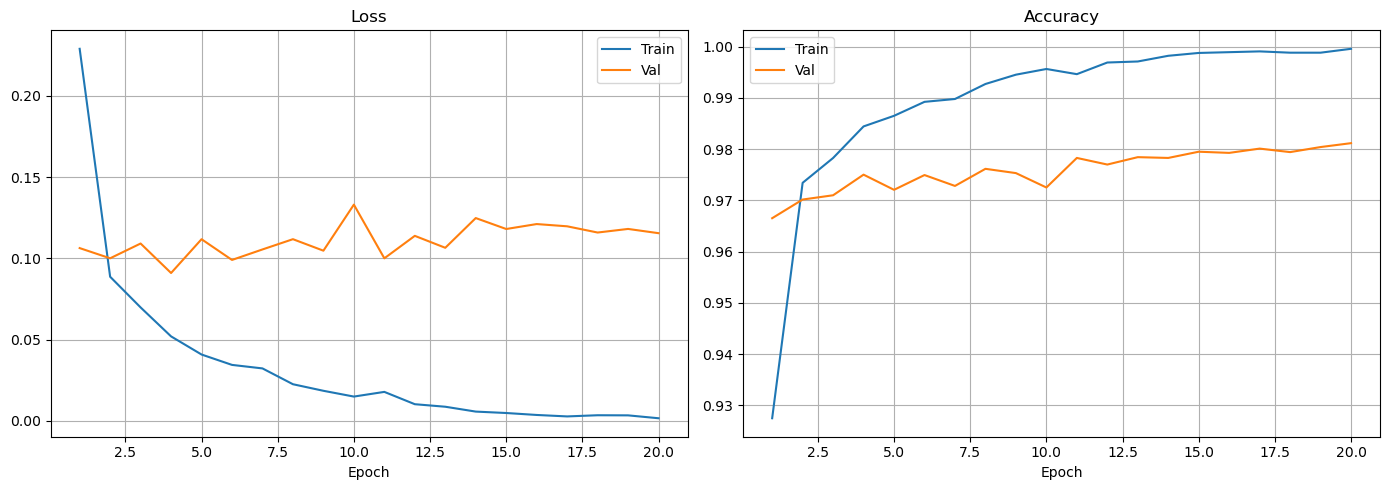

In [8]:
# ── Training curves ───────────────────────────────────────────────────────────
epochs = range(1, NUM_EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, history["train_loss"], label="Train")
axes[0].plot(epochs, history["val_loss"],   label="Val")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch")
axes[0].legend(); axes[0].grid(True)

axes[1].plot(epochs, history["train_acc"], label="Train")
axes[1].plot(epochs, history["val_acc"],   label="Val")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch")
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()

In [9]:
# ── Load best checkpoint then run full test-set inference ─────────────────────
model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=DEVICE))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        preds  = model(images).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

In [10]:
# ── Per-class accuracy ────────────────────────────────────────────────────────
print("Classification Report")
print("=" * 60)
print(classification_report(
    all_labels, all_preds,
    target_names=CLASSES,
    digits=4
))

Classification Report
                precision    recall  f1-score   support

         graph     0.9917    0.9865    0.9891      5476
         table     0.9861    0.9861    0.9861      1083
       diagram     0.9282    0.9691    0.9482      1067
   meta figure     0.9634    0.9600    0.9617      2249
    photograph     0.9955    0.9917    0.9936      2888
    screenshot     0.9805    0.9742    0.9773       155
circular graph     0.9609    0.9685    0.9647       254

      accuracy                         0.9812     13172
     macro avg     0.9723    0.9766    0.9744     13172
  weighted avg     0.9814    0.9812    0.9812     13172



In [11]:
# ── Collect energy scores on the test set ────────────────────────────────────
def compute_energy_scores(model, loader, device, T=1.0):
    """Compute energy scores for all samples in a DataLoader."""
    model.eval()
    energies = []
    labels = []
    with torch.no_grad():
        for images, lbls in loader:
            images = images.to(device)
            logits = model(images)
            # Energy score: lower = more in-distribution
            energy = -T * torch.logsumexp(logits / T, dim=1)
            energies.extend(energy.cpu().numpy())
            labels.extend(lbls.numpy())
    return np.array(energies), np.array(labels)

energies, labels = compute_energy_scores(model, test_loader, DEVICE)

# ── Choose a threshold ────────────────────────────────────────────────────────
# Target: keep ~95% of in-distribution samples (tune this to your needs)
threshold_90 = np.percentile(energies, 90)
threshold_95 = np.percentile(energies, 95)
threshold_99 = np.percentile(energies, 99)
print(f"Energy range: [{energies.min():.4f}, {energies.max():.4f}]")
print("-------------------------------------------------------")
print(f"Energy threshold (90th percentile): {threshold_90:.4f}")
print("-------------------------------------------------------")
print(f"Energy threshold (95th percentile): {threshold_95:.4f}")
print("-------------------------------------------------------")
print(f"Energy threshold (99th percentile): {threshold_99:.4f}")
threshold = threshold_99

Energy range: [-46.7508, 4.3565]
-------------------------------------------------------
Energy threshold (90th percentile): -5.8314
-------------------------------------------------------
Energy threshold (95th percentile): -4.1323
-------------------------------------------------------
Energy threshold (99th percentile): -1.0669


In [ ]:
# ── Confusion matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=CLASSES, yticklabels=CLASSES, ax=ax
)
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("True",      fontsize=12)
ax.set_title("Confusion Matrix (test set)", fontsize=14)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

# Normalised confusion matrix (row-wise recall)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm_norm, annot=True, fmt=".2f", cmap="Blues",
    xticklabels=CLASSES, yticklabels=CLASSES, ax=ax,
    vmin=0, vmax=1
)
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("True",      fontsize=12)
ax.set_title("Normalised Confusion Matrix", fontsize=14)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("confusion_matrix_normalised.png", dpi=150)
plt.show()

## 6. Save & Export

In [ ]:
# # ── Full checkpoint (weights + metadata) ─────────────────────────────────────
# torch.save({
#     "model_state_dict":     model.state_dict(),
#     "optimizer_state_dict": optimizer.state_dict(),
#     "classes":              CLASSES,
#     "best_val_acc":         best_val_acc,
#     "num_epochs":           NUM_EPOCHS,
# }, "resnet50_full_checkpoint.pth")
# print("Full checkpoint saved → resnet50_full_checkpoint.pth")

# # ── TorchScript export (portable, no class definition needed at inference) ────
# model.eval()
# scripted = torch.jit.script(model)
# scripted.save("resnet50_scripted.pt")
# print("TorchScript model saved → resnet50_scripted.pt")

Full checkpoint saved → resnet50_full_checkpoint.pth
TorchScript model saved → resnet50_scripted.pt


In [ ]:
# # ── Quick inference helper ────────────────────────────────────────────────────
# def predict(image_path, model, transform, device, top_k=3):
#     """Return top-k (class_name, probability) tuples for a single image."""
#     image  = Image.open(image_path).convert("RGB")
#     tensor = transform(image).unsqueeze(0).to(device)
#     with torch.no_grad():
#         logits = model(tensor)
#         probs  = torch.softmax(logits, dim=1).squeeze().cpu().numpy()
#     top_idx = probs.argsort()[::-1][:top_k]
#     return [(IDX_TO_CLASS[i], float(probs[i])) for i in top_idx]


# # Example — replace with any image path
# SAMPLE_IMAGE = test_samples[0][0]
# results = predict(SAMPLE_IMAGE, model, test_transform, DEVICE)
# print(f"Predictions for: {os.path.basename(SAMPLE_IMAGE)}")
# for cls, prob in results:
#     print(f"  {cls:20s}: {prob:.4f}")

Predictions for: 2014_06909689-Figure3-1subFig-2.png
  photograph          : 1.0000
  meta figure         : 0.0000
  graph               : 0.0000


In [15]:
# ── Full checkpoint (weights + metadata) ─────────────────────────────────────
torch.save({
    "model_state_dict":     model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "classes":              CLASSES,
    "best_val_acc":         best_val_acc,
    "num_epochs":           NUM_EPOCHS,
    "energy_threshold":     threshold,   # <-- save the threshold too!
}, "resnet50_full_checkpoint.pth")
print("Full checkpoint saved → resnet50_full_checkpoint.pth")

# ── TorchScript export ────────────────────────────────────────────────────────
model.eval()
scripted = torch.jit.script(model)
scripted.save("resnet50_scripted.pt")
print("TorchScript model saved → resnet50_scripted.pt")

Full checkpoint saved → resnet50_full_checkpoint.pth
TorchScript model saved → resnet50_scripted.pt


In [16]:
# ── Updated inference helper with OOD detection ───────────────────────────────
def predict_with_other(image_path, model, transform, device,
                       energy_threshold=None, T=1.0, top_k=3):
    image  = Image.open(image_path).convert("RGB")
    tensor = transform(image).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        logits = model(tensor)
        probs  = torch.softmax(logits, dim=1).squeeze().cpu().numpy()
        energy = float(-T * torch.logsumexp(logits / T, dim=1).cpu())

    if energy_threshold is not None and energy > energy_threshold:
        return "other", float(np.max(probs)), energy

    top_idx = probs.argsort()[::-1][:top_k]
    results = [(IDX_TO_CLASS[i], float(probs[i])) for i in top_idx]
    return results[0][0], results[0][1], energy

# ── Example usage ─────────────────────────────────────────────────────────────
SAMPLE_IMAGE = test_samples[0][0]
cls, conf, energy = predict_with_other(
    SAMPLE_IMAGE, model, test_transform, DEVICE,
    energy_threshold=threshold
)
print(f"Predicted: {cls} (confidence: {conf:.4f}, energy: {energy:.4f})")

Predicted: photograph (confidence: 1.0000, energy: -10.7391)


In [18]:
import torch
ckpt = torch.load("resnet50_full_checkpoint.pth", map_location="cpu", weights_only=False)
print(ckpt["energy_threshold"])

-1.0668595
